In [1]:
import random
import numpy as np

X = [5, 3, 5, 5, 2, 4, 1, 6, 3, 1]  # 데이터 셋

eyes = [1, 2, 3, 4, 5, 6]
p = np.zeros([6])


def learn_generator(X, p):
    for i in range(len(X)):
        p[X[i] - 1] += 1
    p = p / len(X)


def generate():
    return random.choices(eyes, p)


learn_generator(X, p)
print(generate(), generate(), generate(), generate())


[3] [5] [3] [3]


In [2]:
import numpy as np

X = np.array(
    [
        [169, 70],
        [172, 68],
        [175, 78],
        [163, 58],
        [180, 80],
        [159, 76],
        [158, 52],
        [173, 69],
        [180, 75],
        [155, 50],
        [187, 90],
        [170, 66],
    ]
)

m = np.mean(X, axis=0)
cv = np.cov(X, rowvar=False)

gen = np.random.multivariate_normal(m, cv, 5)

print(gen)


[[154.36412694  58.0496479 ]
 [175.59574727  72.82902079]
 [187.03816879  92.18994101]
 [181.35148807  80.20914861]
 [158.77733455  61.48800191]]


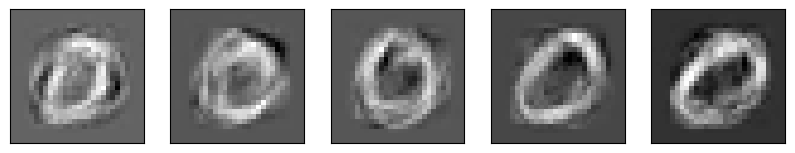

In [3]:
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
X = x_train[np.isin(y_train, [0])]
X = X.reshape((X.shape[0], 28*28))

m = np.mean(X, axis=0)
cv = np.cov(X, rowvar=False)

gen = np.random.multivariate_normal(m, cv, 5)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(gen[i].reshape((28,28)), cmap='gray')
    plt.xticks([])
    plt.yticks([])

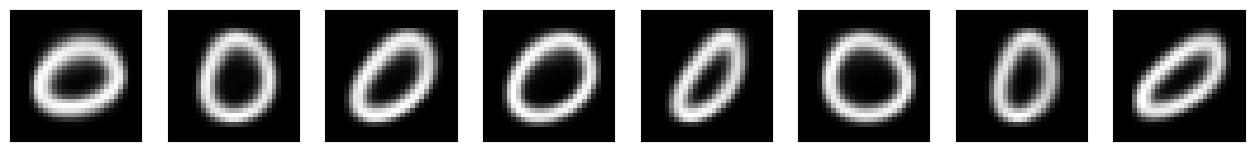

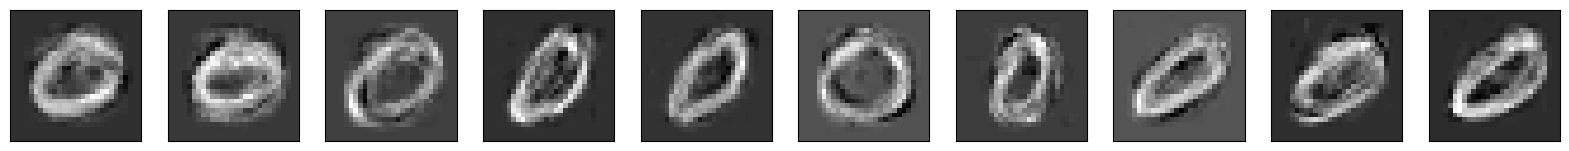

In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.mixture import GaussianMixture

(x_train, y_train), (x_test, y_test) = mnist.load_data()
X = x_train[np.isin(y_train,[0])]
X = X.reshape((X.shape[0], 28*28))

k=8 # 가우시안 개수

gm = GaussianMixture(n_components=k).fit(X)

gen = gm.sample(n_samples=10)

import matplotlib.pyplot as plt

plt.figure(figsize=(20,4))
for i in range(k):
    plt.subplot(1, 10, i+1)
    plt.imshow(gm.means_[i].reshape((28,28)), cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.show()

plt.figure(figsize=(20,4))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(gen[0][i].reshape((28,28)), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    
plt.show()

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0355 - val_loss: 0.0062
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0058 - val_loss: 0.0047
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0036 - val_loss: 0.0035
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0035 - val_loss: 0.0034
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - loss: 0.0033 - val_loss: 0.0032
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0032 - val_loss: 0.0032
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - loss: 0.0031 - val_loss: 0.0031
Epoch 12/50
469/469 ━━━━━━━━━━

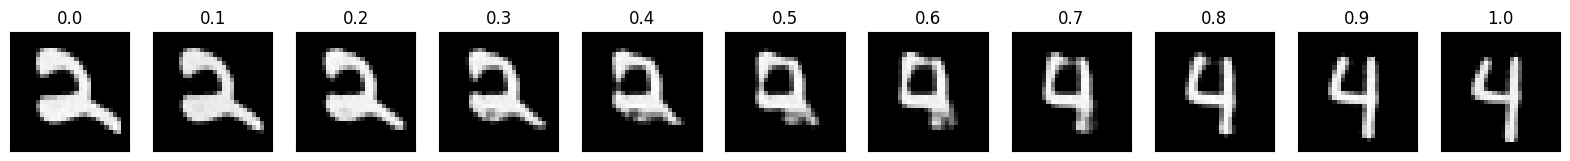

In [6]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Conv2D, Conv2DTranspose
from tensorflow.keras.models import Model

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train=x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
x_train=np.reshape(x_train,(len(x_train), 28,28,1))
x_test=np.reshape(x_test,(len(x_test), 28,28,1))


zdim = 32 # 잠복 공간의 차원

encoder_input = Input(shape=(28,28,1))
x = Conv2D(32, (3,3), activation='relu', padding='same', strides=(1,1))(encoder_input)
x = Conv2D(64, (3,3), activation='relu', padding='same', strides=(2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same', strides=(2,2))(x)
x = Conv2D(64, (3,3), activation='relu', padding='same', strides=(1,1))(x)
x = Flatten()(x)
encoder_output = Dense(zdim)(x)
model_encoder = Model(encoder_input, encoder_output)

decoder_input = Input(shape=(zdim,))
x = Dense(3136)(decoder_input)
x = Reshape((7,7,64))(x)
x = Conv2DTranspose(64, (3,3), activation='relu', padding='same', strides=(1,1))(x)
x = Conv2DTranspose(64, (3,3), activation='relu', padding='same', strides=(2,2))(x)
x = Conv2DTranspose(32, (3,3), activation='relu', padding='same', strides=(2,2))(x)
x = Conv2DTranspose(1, (3,3), activation='relu', padding='same', strides=(1,1))(x)
decoder_output = x
model_decoder = Model(decoder_input, decoder_output)

model_input = encoder_input
model_output = model_decoder(encoder_output)
model = Model(model_input, model_output)

model.compile(optimizer='Adam', loss='mse')
model.fit(x_train, x_train, epochs=50, batch_size=128, shuffle=True, validation_data=(x_test, x_test))

import matplotlib.pyplot as plt

i = np.random.randint(x_test.shape[0])
j = np.random.randint(x_test.shape[0])
x = np.array((x_test[i], x_test[j]))
z = model_encoder.predict(x)

zz = np.zeros((11, zdim))
alpha = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]
for i in range(11):
    zz[i] = (1.0 - alpha[i]) * z[0]+alpha[i]*z[1]
    
gen = model_decoder.predict(zz)

plt.figure(figsize=(20,4))
for i in range(11):
    plt.subplot(1,11,i+1)
    plt.imshow(gen[i].reshape(28,28), cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.title(str(alpha[i]))